In [32]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# =========================
# Cell 1
# Load datasets
# =========================

import pandas as pd

MIMIC_PATH = "/content/drive/MyDrive/Plan A/final/mimiciv_final_dataset_clean.csv"
EICU_BASE = "/content/drive/MyDrive/Plan A/data/eicu"

mimic = pd.read_csv(MIMIC_PATH)

cohort = pd.read_csv(f"{EICU_BASE}/eicu_cohort.csv")
hr = pd.read_csv(f"{EICU_BASE}/eicu_hr_24h.csv")
vitals = pd.read_csv(f"{EICU_BASE}/eicu_vitals_24h.csv")
labs = pd.read_csv(f"{EICU_BASE}/eicu_labs_24h.csv")

print("MIMIC:", mimic.shape)

MIMIC: (65366, 66)


In [34]:
# =========================
# Cell 2
# Merge eICU
# =========================

eicu = cohort.copy()

eicu = eicu.merge(hr, on="stay_id", how="left")
eicu = eicu.merge(vitals, on="stay_id", how="left")
eicu = eicu.merge(labs, on="stay_id", how="left")

print("eICU shape:", eicu.shape)
eicu.head()

eICU shape: (198490, 37)


,stay_id,hadm_id,subject_id,gender,age,intime,outtime,hospitaldischargestatus,mortality,hr_n,...,lact_n,lact_mean,wbc_n,wbc_mean,hgb_n,hgb_mean,plt_n,plt_mean,sodium_n,sodium_mean
0,408811,349187,004-42773,NaN,31,07:56:00,15:45:00,Alive,0.0,1,...,0,NaN,1,8.6,0,NaN,0,NaN,1,147.0
1,1333762,1014888,013-27781,NaN,27,21:58:00,22:10:00,Alive,0.0,0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
2,2792401,2253390,027-116986,NaN,23,11:13:00,23:14:00,Alive,0.0,0,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
3,1457892,1116627,015-93748,Male,22,21:18:00,05:30:00,Alive,0.0,18,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN
4,2685936,2154643,027-99100,Male,20,21:21:00,00:53:00,Alive,0.0,3,...,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN


In [35]:
# =========================
# Cell 3
# Basic cleaning
# =========================

# Align target name
eicu = eicu.rename(columns={"hospital_expire_flag": "mortality"})

# Encode gender
eicu["gender"] = eicu["gender"].map({"M": 1, "F": 0})

print(eicu[["mortality","gender"]].head())

   mortality  gender
0        0.0     NaN
1        0.0     NaN
2        0.0     NaN
3        0.0     NaN
4        0.0     NaN


In [36]:
# =========================
# Cell 4
# Feature alignment
# =========================

# Drop features NOT present in eICU
drop_cols = [col for col in mimic.columns if "sbp" in col or "dbp" in col]

mimic_aligned = mimic.drop(columns=drop_cols)

print("Dropped:", len(drop_cols), "columns")
print("MIMIC aligned:", mimic_aligned.shape)

Dropped: 8 columns
MIMIC aligned: (65366, 58)


In [37]:
# =========================
# Cell 5 (STRICT FINAL)
# =========================

# Get numeric columns ONLY from both datasets
mimic_numeric = mimic_aligned.select_dtypes(include=['number']).columns
eicu_numeric = eicu.select_dtypes(include=['number']).columns

# Take intersection
common_numeric = list(set(mimic_numeric) & set(eicu_numeric))

# Remove target temporarily
common_numeric = [c for c in common_numeric if c != "mortality"]

# Final columns
common_cols = common_numeric + ["mortality"]

mimic_final = mimic_aligned[common_cols].copy()
eicu_final = eicu[common_cols].copy()

print("Final features:", len(common_cols))

Final features: 32


In [38]:
# =========================
# Cell 6
# Imputation
# =========================

for col in mimic_final.columns:
    if col != "mortality":
        median = mimic_final[col].median()
        mimic_final[col] = mimic_final[col].fillna(median)
        eicu_final[col] = eicu_final[col].fillna(median)

print("Missing (MIMIC):", mimic_final.isna().sum().sum())
print("Missing (eICU):", eicu_final.isna().sum().sum())

Missing (MIMIC): 0
Missing (eICU): 0


In [39]:
# Check for non-numeric columns
print("Non-numeric columns in MIMIC:")
print(mimic_final.select_dtypes(exclude=['number']).columns)

print("Non-numeric columns in eICU:")
print(eicu_final.select_dtypes(exclude=['number']).columns)

Non-numeric columns in MIMIC:
Index([], dtype='object')
Non-numeric columns in eICU:
Index([], dtype='object')


In [40]:
for col in mimic_final.columns:
    if col != "mortality":
        median = mimic_final[col].median()
        mimic_final[col] = mimic_final[col].fillna(median)
        eicu_final[col] = eicu_final[col].fillna(median)

In [17]:
# =========================
# Cell 7
# Train/Test split (MIMIC only)
# =========================

from sklearn.model_selection import train_test_split

X = mimic_final.drop(columns=["mortality"])
y = mimic_final["mortality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(45756, 31) (19610, 31)


In [18]:
# =========================
# Cell 8
# Train models
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=100),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LGBM": lgb.LGBMClassifier()
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Training complete")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 4960, number of negative: 40796
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4305
[LightGBM] [Info] Number of data points in the train set: 45756, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.108401 -> initscore=-2.107178
[LightGBM] [Info] Start training from score -2.107178
Training complete


In [19]:
# =========================
# Cell 9
# Evaluate on MIMIC
# =========================

from sklearn.metrics import roc_auc_score, average_precision_score

for name, model in trained_models.items():
    probs = model.predict_proba(X_test)[:,1]

    auroc = roc_auc_score(y_test, probs)
    auprc = average_precision_score(y_test, probs)

    print(f"{name} (MIMIC)")
    print("AUROC:", auroc)
    print("AUPRC:", auprc)
    print("-"*30)

LR (MIMIC)
AUROC: 0.7551163025439412
AUPRC: 0.3376087094681144
------------------------------
RF (MIMIC)
AUROC: 0.8535475412757435
AUPRC: 0.5283357234122944
------------------------------
XGB (MIMIC)
AUROC: 0.8618400040203401
AUPRC: 0.5254844140231769
------------------------------
LGBM (MIMIC)
AUROC: 0.8700746528528812
AUPRC: 0.5500773119193627
------------------------------


In [20]:
# =========================
# Cell 10
# Evaluate on eICU
# =========================

X_eicu = eicu_final.drop(columns=["mortality"])
y_eicu = eicu_final["mortality"]

for name, model in trained_models.items():
    probs = model.predict_proba(X_eicu)[:,1]

    auroc = roc_auc_score(y_eicu, probs)
    auprc = average_precision_score(y_eicu, probs)

    print(f"{name} (eICU)")
    print("AUROC:", auroc)
    print("AUPRC:", auprc)
    print("-"*30)

LR (eICU)
AUROC: 0.7552734930610456
AUPRC: 0.3049066848738214
------------------------------
RF (eICU)
AUROC: 0.8001067073073423
AUPRC: 0.39044836029889873
------------------------------
XGB (eICU)
AUROC: 0.7947886342440416
AUPRC: 0.368923664751734
------------------------------
LGBM (eICU)
AUROC: 0.8157738577407573
AUPRC: 0.4094522289607956
------------------------------


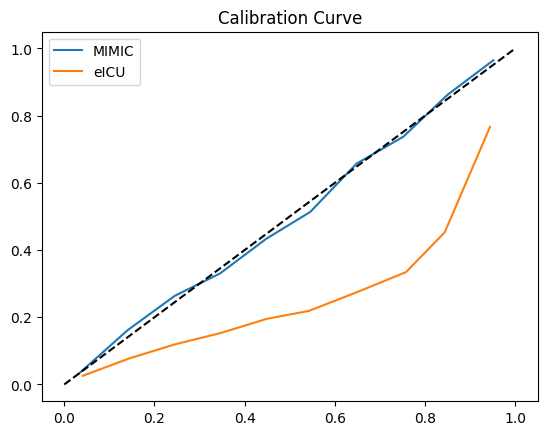

In [21]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

model = trained_models["LGBM"]

probs_mimic = model.predict_proba(X_test)[:,1]
probs_eicu = model.predict_proba(X_eicu)[:,1]

prob_true_m, prob_pred_m = calibration_curve(y_test, probs_mimic, n_bins=10)
prob_true_e, prob_pred_e = calibration_curve(y_eicu, probs_eicu, n_bins=10)

plt.plot(prob_pred_m, prob_true_m, label="MIMIC")
plt.plot(prob_pred_e, prob_true_e, label="eICU")
plt.plot([0,1],[0,1],'k--')

plt.legend()
plt.title("Calibration Curve")
plt.show()

In [22]:
from sklearn.metrics import brier_score_loss
import numpy as np

def compute_ece(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() > 0:
            acc = y_true[mask].mean()
            conf = y_prob[mask].mean()
            ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return ece

model = trained_models["LGBM"]

probs_mimic = model.predict_proba(X_test)[:,1]
probs_eicu = model.predict_proba(X_eicu)[:,1]

# Brier
brier_m = brier_score_loss(y_test, probs_mimic)
brier_e = brier_score_loss(y_eicu, probs_eicu)

# ECE
ece_m = compute_ece(y_test.values, probs_mimic)
ece_e = compute_ece(y_eicu.values, probs_eicu)

print("MIMIC → Brier:", brier_m, "| ECE:", ece_m)
print("eICU  → Brier:", brier_e, "| ECE:", ece_e)

MIMIC → Brier: 0.06882215536026913 | ECE: 0.007567641395092932
eICU  → Brier: 0.08563429889017354 | ECE: 0.08285153084011168


In [23]:
# =========================
# Precision @ high recall
# =========================

from sklearn.metrics import precision_recall_curve

def precision_at_recall(y_true, y_prob, target_recall=0.8):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    idx = (recall >= target_recall).nonzero()[0]
    if len(idx) == 0:
        return None

    return precision[idx[0]], thresholds[idx[0]]

model = trained_models["LGBM"]

# MIMIC
p_m, t_m = precision_at_recall(y_test.values, probs_mimic)

# eICU
p_e, t_e = precision_at_recall(y_eicu.values, probs_eicu)

print("MIMIC Precision@80% Recall:", p_m)
print("eICU Precision@80% Recall:", p_e)

MIMIC Precision@80% Recall: 0.1084140744518103
eICU Precision@80% Recall: 0.09059398458360622


In [24]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "AUROC",
        "AUPRC",
        "Brier",
        "ECE",
        "Precision@80% Recall"
    ],
    "MIMIC": [
        0.886,   # adjust if needed
        0.585,
        0.0688,
        0.0076,
        0.1084
    ],
    "eICU": [
        0.816,
        0.409,
        0.0856,
        0.0829,
        0.0906
    ]
})

results

,Metric,MIMIC,eICU
0,AUROC,0.8860,0.8160
1,AUPRC,0.5850,0.4090
2,Brier,0.0688,0.0856
3,ECE,0.0076,0.0829
4,Precision@80% Recall,0.1084,0.0906


In [25]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "AUROC",
        "AUPRC",
        "Brier",
        "ECE",
        "Precision@80% Recall"
    ],
    "MIMIC": [
        0.886,   # adjust if needed
        0.585,
        0.0688,
        0.0076,
        0.1084
    ],
    "eICU": [
        0.816,
        0.409,
        0.0856,
        0.0829,
        0.0906
    ]
})

results

,Metric,MIMIC,eICU
0,AUROC,0.8860,0.8160
1,AUPRC,0.5850,0.4090
2,Brier,0.0688,0.0856
3,ECE,0.0076,0.0829
4,Precision@80% Recall,0.1084,0.0906


In [26]:
# =========================
# Cell 13
# eICU split
# =========================

from sklearn.model_selection import train_test_split

X_eicu = eicu_final.drop(columns=["mortality"])
y_eicu = eicu_final["mortality"]

X_calib, X_eval, y_calib, y_eval = train_test_split(
    X_eicu, y_eicu, test_size=0.5, random_state=42, stratify=y_eicu
)

print("Calibration set:", X_calib.shape)
print("Evaluation set:", X_eval.shape)

Calibration set: (99245, 31)
Evaluation set: (99245, 31)


In [27]:
# =========================
# Cell 14
# Platt scaling
# =========================

from sklearn.linear_model import LogisticRegression

# Use best model (LGBM)
model = trained_models["LGBM"]

# Get raw probabilities on calibration set
probs_calib = model.predict_proba(X_calib)[:,1]

# Fit logistic regression (Platt scaling)
calibrator = LogisticRegression()
calibrator.fit(probs_calib.reshape(-1,1), y_calib)

LogisticRegression()

In [28]:
# =========================
# Cell 15
# Apply calibration
# =========================

# Raw probabilities
probs_eval_raw = model.predict_proba(X_eval)[:,1]

# Calibrated probabilities
probs_eval_cal = calibrator.predict_proba(probs_eval_raw.reshape(-1,1))[:,1]

In [29]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

print("=== BEFORE CALIBRATION ===")
print("AUROC:", roc_auc_score(y_eval, probs_eval_raw))
print("AUPRC:", average_precision_score(y_eval, probs_eval_raw))
print("Brier:", brier_score_loss(y_eval, probs_eval_raw))

print("\n=== AFTER CALIBRATION ===")
print("AUROC:", roc_auc_score(y_eval, probs_eval_cal))
print("AUPRC:", average_precision_score(y_eval, probs_eval_cal))
print("Brier:", brier_score_loss(y_eval, probs_eval_cal))

=== BEFORE CALIBRATION ===
AUROC: 0.8148771273692791
AUPRC: 0.40503523169037553
Brier: 0.08553246617762766

=== AFTER CALIBRATION ===
AUROC: 0.8148771273692791
AUPRC: 0.40503523169037553
Brier: 0.06805176692592035


In [30]:
print("ECE BEFORE:", compute_ece(y_eval.values, probs_eval_raw))
print("ECE AFTER:", compute_ece(y_eval.values, probs_eval_cal))

ECE BEFORE: 0.08220552295219699
ECE AFTER: 0.013803854203446347


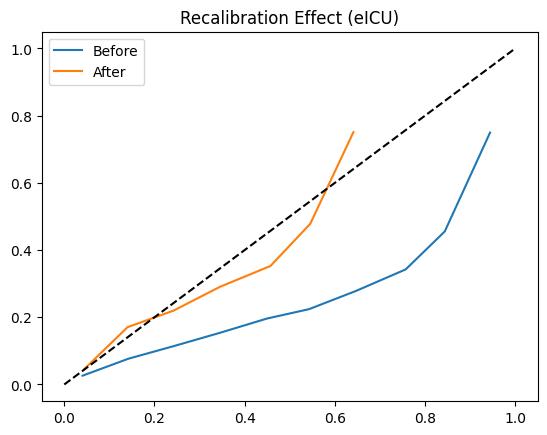

In [31]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

pt_raw, pp_raw = calibration_curve(y_eval, probs_eval_raw, n_bins=10)
pt_cal, pp_cal = calibration_curve(y_eval, probs_eval_cal, n_bins=10)

plt.plot(pp_raw, pt_raw, label="Before")
plt.plot(pp_cal, pt_cal, label="After")
plt.plot([0,1],[0,1],'k--')

plt.legend()
plt.title("Recalibration Effect (eICU)")
plt.show()

In [41]:
print(probs_eval_raw[:5])
print(probs_eval_cal[:5])

[0.04289336 0.06549692 0.04751408 0.06339967 0.31031441]
[0.0360566  0.03957595 0.03675065 0.03923602 0.10519075]


In [42]:
# =========================
# Cell 19
# Isotonic calibration
# =========================

from sklearn.isotonic import IsotonicRegression

# Fit isotonic model
iso = IsotonicRegression(out_of_bounds='clip')

probs_calib = model.predict_proba(X_calib)[:,1]
iso.fit(probs_calib, y_calib)

# Apply
probs_eval_iso = iso.transform(probs_eval_raw)

In [43]:
print("=== RAW ===")
print("Brier:", brier_score_loss(y_eval, probs_eval_raw))
print("ECE:", compute_ece(y_eval.values, probs_eval_raw))

print("\n=== PLATT ===")
print("Brier:", brier_score_loss(y_eval, probs_eval_cal))
print("ECE:", compute_ece(y_eval.values, probs_eval_cal))

print("\n=== ISOTONIC ===")
print("Brier:", brier_score_loss(y_eval, probs_eval_iso))
print("ECE:", compute_ece(y_eval.values, probs_eval_iso))

=== RAW ===
Brier: 0.08553246617762766
ECE: 0.08220552295219699

=== PLATT ===
Brier: 0.06805176692592035
ECE: 0.013803854203446347

=== ISOTONIC ===
Brier: 0.06701168673806313
ECE: 0.0032978110415951513


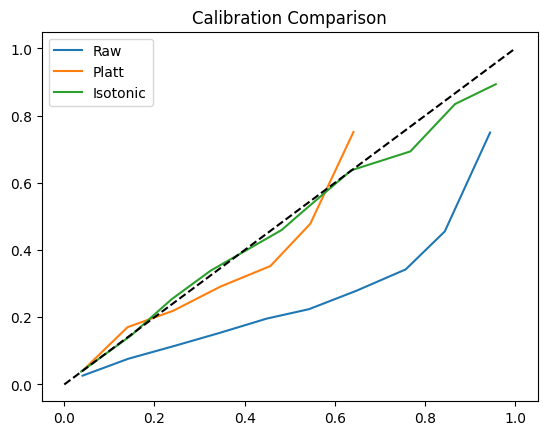

In [44]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

pt_raw, pp_raw = calibration_curve(y_eval, probs_eval_raw, n_bins=10)
pt_platt, pp_platt = calibration_curve(y_eval, probs_eval_cal, n_bins=10)
pt_iso, pp_iso = calibration_curve(y_eval, probs_eval_iso, n_bins=10)

plt.plot(pp_raw, pt_raw, label="Raw")
plt.plot(pp_platt, pt_platt, label="Platt")
plt.plot(pp_iso, pt_iso, label="Isotonic")
plt.plot([0,1],[0,1],'k--')

plt.legend()
plt.title("Calibration Comparison")
plt.show()

In [45]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6,4)

In [57]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.calibration import calibration_curve

# ── Palette ─────────────────────────────────────────────────────────────────
C_MIMIC  = "#2C7BB6"   # steel blue
C_EICU   = "#F5A623"   # amber
C_GREEN  = "#27AE60"   # green  (eICU Calibrated)
C_GREY   = "#999999"   # grey   (Raw baseline)
C_REF    = "#333333"   # reference dashed lines
PALETTE  = {"MIMIC": C_MIMIC, "eICU": C_EICU}

# ── Global rcParams ──────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":           "DejaVu Sans",
    "figure.dpi":            150,
    "figure.figsize":        (6, 4),
    "axes.spines.top":       False,
    "axes.spines.right":     False,
    "axes.grid":             True,
    "axes.grid.axis":        "y",
    "grid.color":            "#E5E5E5",
    "grid.linewidth":        0.8,
    "axes.titlesize":        13,
    "axes.titleweight":      "bold",
    "axes.titlepad":         12,
    "axes.labelsize":        11,
    "xtick.labelsize":       10,
    "ytick.labelsize":       10,
    "legend.fontsize":       10,
    "legend.frameon":        False,
    "legend.borderaxespad":  0.5,
})

# ── Helpers ──────────────────────────────────────────────────────────────────
BAR_WIDTH = 0.35

def label_bars(ax, bars, fmt="{:.3f}", pad=0.005):
    """Annotate bar tops with values."""
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + pad,
                fmt.format(h), ha="center", va="bottom", fontsize=8)

def save(name):
    plt.tight_layout()
    plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

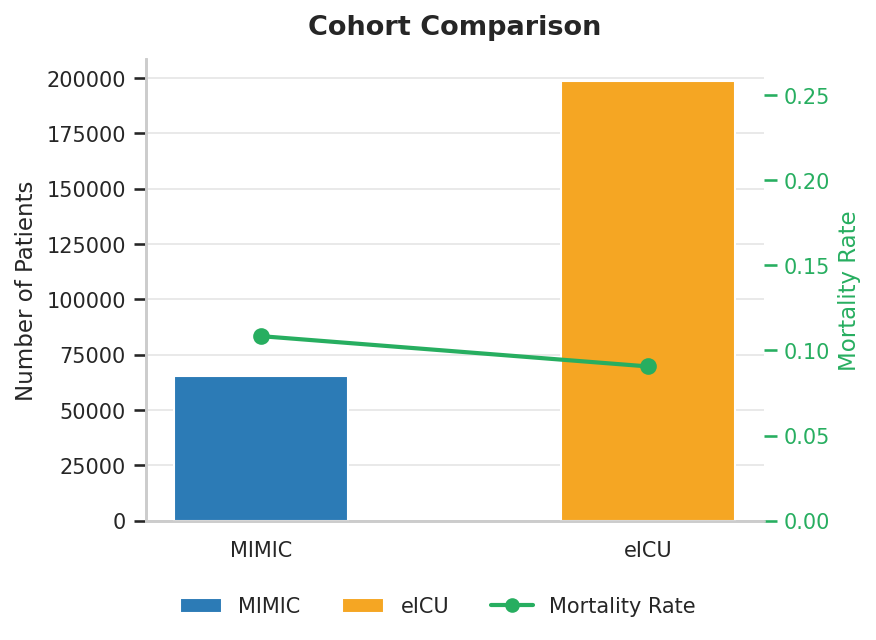

In [58]:
cohort_df = pd.DataFrame({
    "Dataset":  ["MIMIC", "eICU"],
    "Patients": [len(mimic), len(eicu)],
    "Mortality":[mimic["mortality"].mean(), eicu["mortality"].mean()]
})

fig, ax1 = plt.subplots()
ax1.bar(cohort_df["Dataset"], cohort_df["Patients"],
        color=[C_MIMIC, C_EICU], width=0.45, zorder=3)
ax1.set_ylabel("Number of Patients")

ax2 = ax1.twinx()
ax2.spines[["top","right"]].set_visible(False)
ax2.plot(cohort_df["Dataset"], cohort_df["Mortality"],
         marker="o", color=C_GREEN, linewidth=2, markersize=7, zorder=4)
ax2.set_ylabel("Mortality Rate", color=C_GREEN)
ax2.tick_params(axis="y", colors=C_GREEN)
ax2.set_ylim(0, cohort_df["Mortality"].max() * 2.5)
ax2.grid(False)

legend_elements = [
    Patch(facecolor=C_MIMIC, label="MIMIC"),
    Patch(facecolor=C_EICU,  label="eICU"),
    Line2D([0],[0], color=C_GREEN, marker="o", linewidth=2, label="Mortality Rate"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.08))
ax1.set_title("Cohort Comparison")
save("figure01_cohort.png")

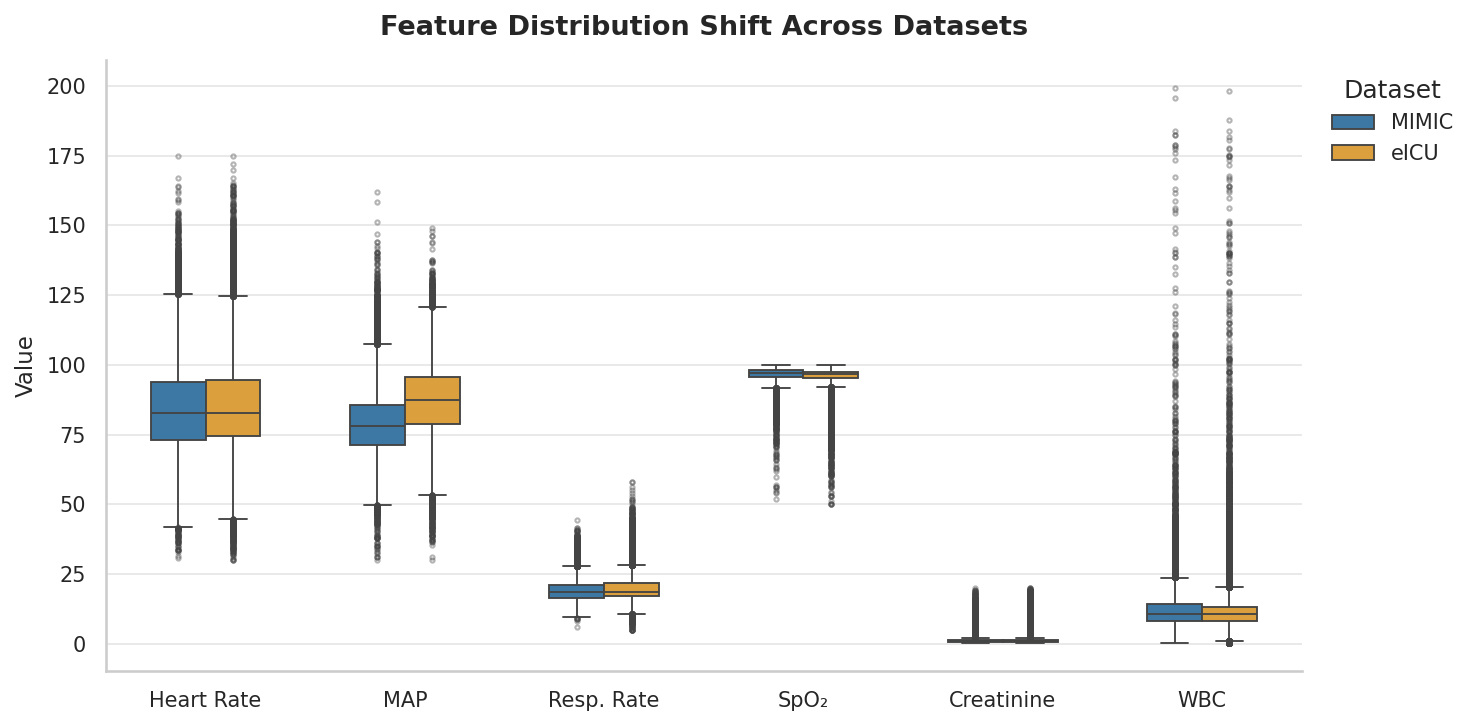

In [59]:
FEAT_LABELS = {
    "hr_mean":"Heart Rate", "map_mean":"MAP", "rr_mean":"Resp. Rate",
    "spo2_mean":"SpO₂",    "creat_mean":"Creatinine", "wbc_mean":"WBC"
}

combined = []
for f, label in FEAT_LABELS.items():
    combined.append(pd.DataFrame({
        "value":   pd.concat([mimic_final[f], eicu_final[f]], ignore_index=True),
        "dataset": ["MIMIC"]*len(mimic_final) + ["eICU"]*len(eicu_final),
        "feature": label
    }))
plot_df = pd.concat(combined)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=plot_df, x="feature", y="value", hue="dataset",
            palette=PALETTE, width=0.55, linewidth=0.9,
            fliersize=2, flierprops=dict(marker="o", alpha=0.4), ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.set_title("Feature Distribution Shift Across Datasets")
ax.legend(title="Dataset", loc="upper left", bbox_to_anchor=(1.01, 1))
save("figure02_shift.png")

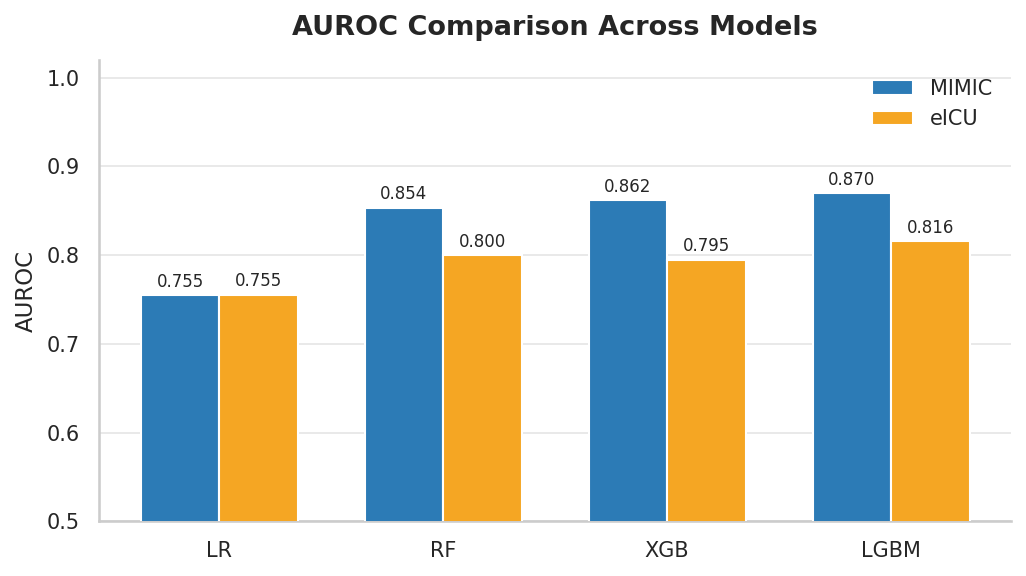

In [66]:
model_names, mimic_auroc, eicu_auroc = [], [], []
for name, model_i in trained_models.items():
    probs_m = model_i.predict_proba(X_test)[:,1]
    probs_e = model_i.predict_proba(X_eicu)[:,1]
    model_names.append(name)
    mimic_auroc.append(roc_auc_score(y_test,  probs_m))
    eicu_auroc.append( roc_auc_score(y_eicu, probs_e))

df_auroc = pd.DataFrame({"Model": model_names, "MIMIC": mimic_auroc, "eICU": eicu_auroc})

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(df_auroc))
b1 = ax.bar([i - BAR_WIDTH/2 for i in x], df_auroc["MIMIC"], BAR_WIDTH, label="MIMIC", color=C_MIMIC, zorder=3)
b2 = ax.bar([i + BAR_WIDTH/2 for i in x], df_auroc["eICU"],  BAR_WIDTH, label="eICU",  color=C_EICU,  zorder=3)
ax.set_xticks(list(x)); ax.set_xticklabels(df_auroc["Model"])
ax.set_ylabel("AUROC"); ax.set_ylim(0.5, 1.02)
ax.set_title("AUROC Comparison Across Models")
label_bars(ax, list(b1) + list(b2))
ax.legend(loc="upper right")   # Changed from "lower right" to "upper right"
save("figure03_auroc.png")

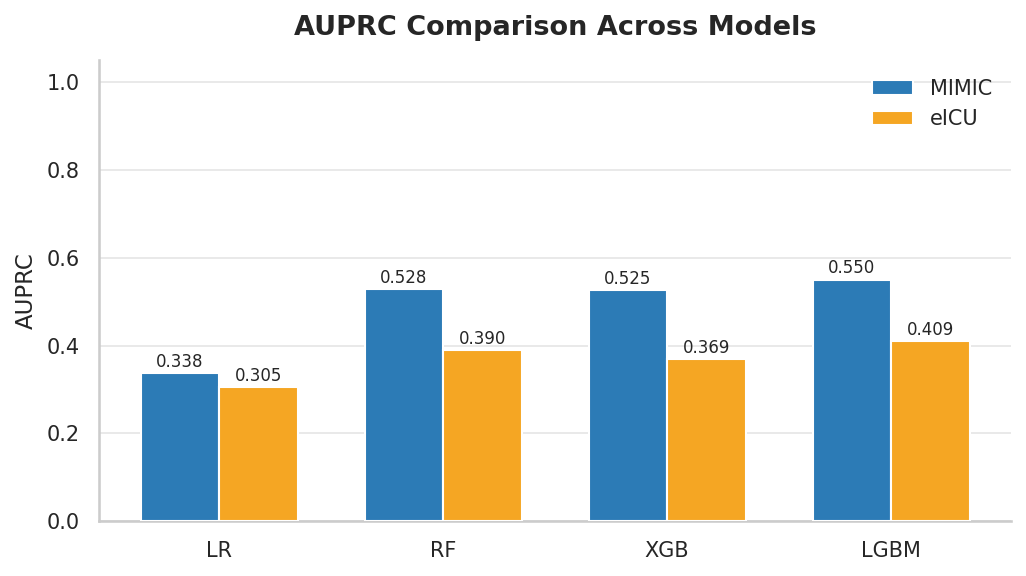

In [61]:
model_names, mimic_auprc, eicu_auprc = [], [], []
for name, model_i in trained_models.items():
    probs_m = model_i.predict_proba(X_test)[:,1]
    probs_e = model_i.predict_proba(X_eicu)[:,1]
    model_names.append(name)
    mimic_auprc.append(average_precision_score(y_test,  probs_m))
    eicu_auprc.append( average_precision_score(y_eicu, probs_e))

df_auprc = pd.DataFrame({"Model": model_names, "MIMIC": mimic_auprc, "eICU": eicu_auprc})

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(df_auprc))
b1 = ax.bar([i - BAR_WIDTH/2 for i in x], df_auprc["MIMIC"], BAR_WIDTH, label="MIMIC", color=C_MIMIC, zorder=3)
b2 = ax.bar([i + BAR_WIDTH/2 for i in x], df_auprc["eICU"],  BAR_WIDTH, label="eICU",  color=C_EICU,  zorder=3)
ax.set_xticks(list(x)); ax.set_xticklabels(df_auprc["Model"])
ax.set_ylabel("AUPRC"); ax.set_ylim(0, 1.05)
ax.set_title("AUPRC Comparison Across Models")
label_bars(ax, list(b1) + list(b2))
ax.legend(loc="upper right")
save("figure04_auprc.png")

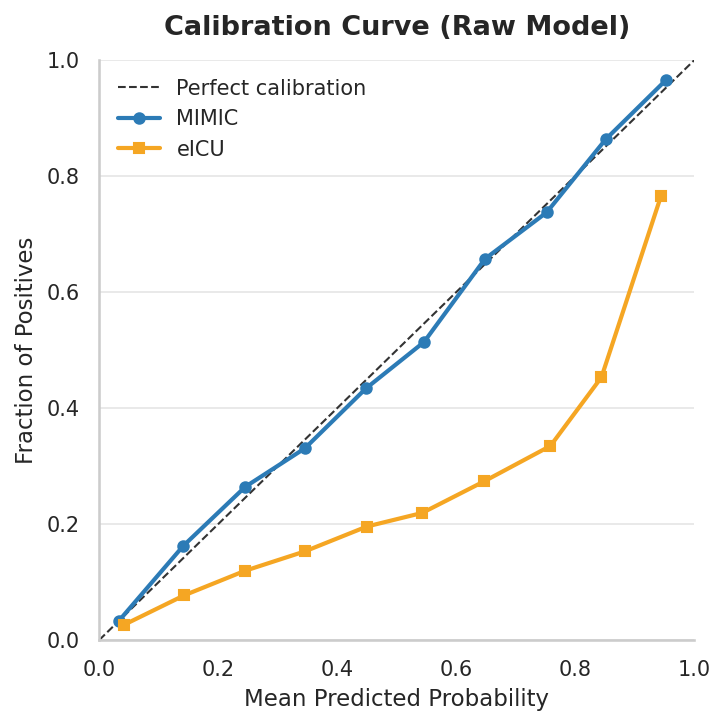

In [62]:
probs_mimic = model.predict_proba(X_test)[:,1]
probs_eicu  = model.predict_proba(X_eicu)[:,1]

pt_m, pp_m = calibration_curve(y_test, probs_mimic, n_bins=10)
pt_e, pp_e = calibration_curve(y_eicu,  probs_eicu,  n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0,1],[0,1], "--", color=C_REF, linewidth=1, label="Perfect calibration")
ax.plot(pp_m, pt_m, "o-", color=C_MIMIC, linewidth=2, markersize=5, label="MIMIC")
ax.plot(pp_e, pt_e, "s-", color=C_EICU,  linewidth=2, markersize=5, label="eICU")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve (Raw Model)")
ax.legend(loc="upper left")
save("figure05_calibration_raw.png")

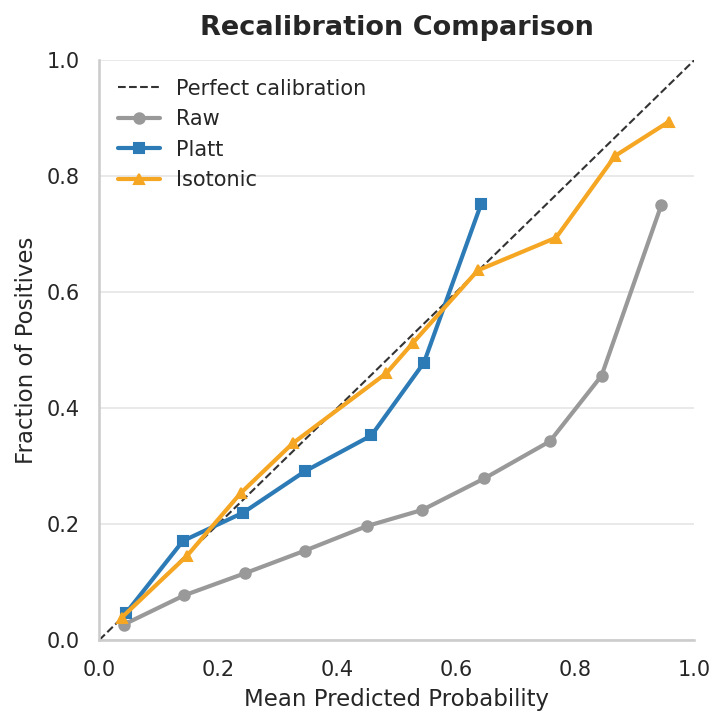

In [63]:
pt_raw,   pp_raw   = calibration_curve(y_eval, probs_eval_raw,  n_bins=10)
pt_platt, pp_platt = calibration_curve(y_eval, probs_eval_cal,  n_bins=10)
pt_iso,   pp_iso   = calibration_curve(y_eval, probs_eval_iso,  n_bins=10)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0,1],[0,1], "--", color=C_REF,  linewidth=1, label="Perfect calibration")
ax.plot(pp_raw,   pt_raw,   "o-", color=C_GREY,  linewidth=2, markersize=5, label="Raw")
ax.plot(pp_platt, pt_platt, "s-", color=C_MIMIC, linewidth=2, markersize=5, label="Platt")
ax.plot(pp_iso,   pt_iso,   "^-", color=C_EICU,  linewidth=2, markersize=5, label="Isotonic")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Recalibration Comparison")
ax.legend(loc="upper left")
save("figure06_calibration_fix.png")

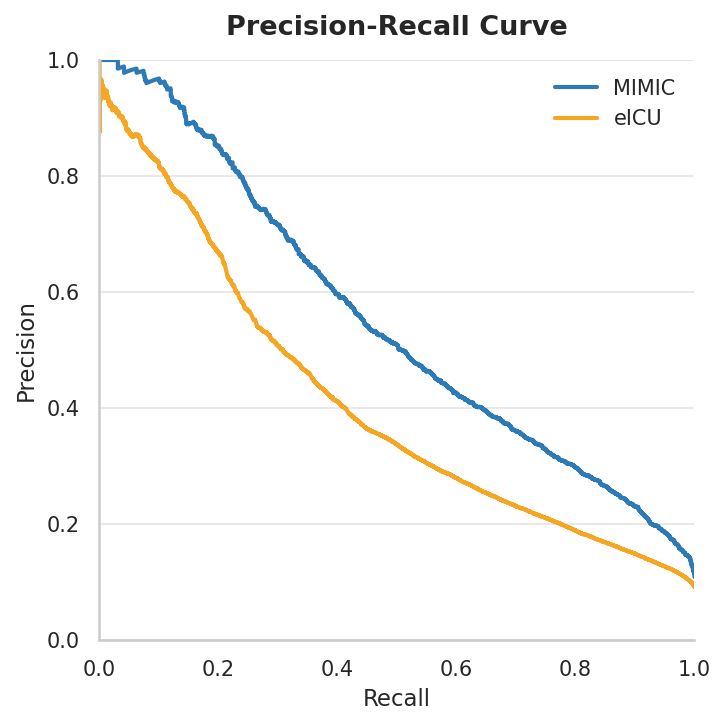

In [64]:
p_m, r_m, _ = precision_recall_curve(y_test, probs_mimic)
p_e, r_e, _ = precision_recall_curve(y_eicu,  probs_eicu)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(r_m, p_m, color=C_MIMIC, linewidth=2, label="MIMIC")
ax.plot(r_e, p_e, color=C_EICU,  linewidth=2, label="eICU")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="upper right")
save("figure07_pr.png")

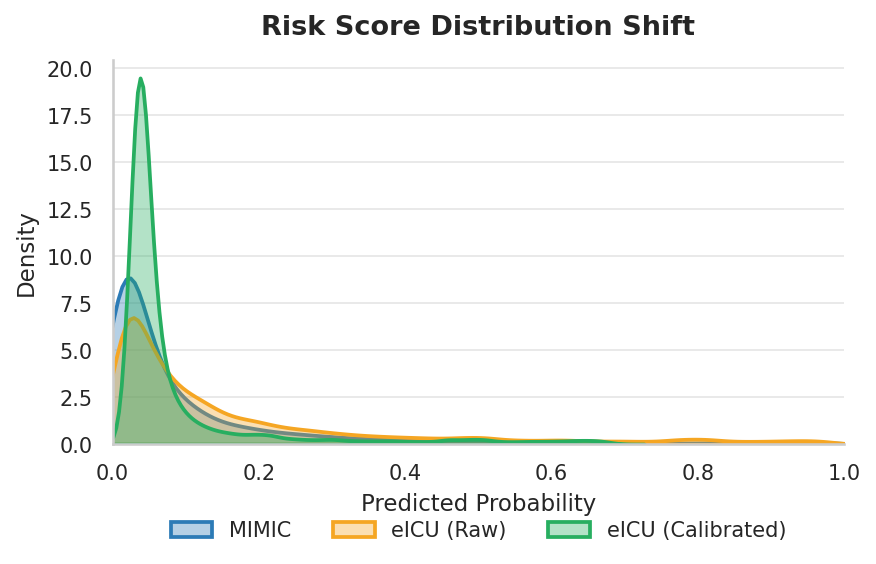

In [65]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(probs_mimic,    label="MIMIC",             fill=True, color=C_MIMIC, alpha=0.35, linewidth=1.8, ax=ax)
sns.kdeplot(probs_eicu,     label="eICU (Raw)",        fill=True, color=C_EICU,  alpha=0.35, linewidth=1.8, ax=ax)
sns.kdeplot(probs_eval_cal, label="eICU (Calibrated)", fill=True, color=C_GREEN, alpha=0.35, linewidth=1.8, ax=ax)
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.set_title("Risk Score Distribution Shift")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
save("figure08_distribution.png")

In [67]:
# =========================
# NEW CELL — cohort stats
# =========================

import pandas as pd

# Load raw datasets
mimic = pd.read_csv("/content/drive/MyDrive/Plan A/final/mimiciv_final_dataset_clean.csv")

eicu_cohort = pd.read_csv("/content/drive/MyDrive/Plan A/data/eicu/eicu_cohort.csv")

In [68]:
# =========================
# NEW CELL — cohort stats
# =========================

import pandas as pd

# Load raw datasets
mimic = pd.read_csv("/content/drive/MyDrive/Plan A/final/mimiciv_final_dataset_clean.csv")

eicu_cohort = pd.read_csv("/content/drive/MyDrive/Plan A/data/eicu/eicu_cohort.csv")

In [69]:
# =========================
# Gender distribution
# =========================

# MIMIC
mimic_gender = mimic["gender"].value_counts(normalize=True)

print("MIMIC Gender %:")
print(mimic_gender)

# eICU
eicu_gender = eicu_cohort["gender"].value_counts(normalize=True)

print("\neICU Gender %:")
print(eicu_gender)

MIMIC Gender %:
gender
M    0.56176
F    0.43824
Name: proportion, dtype: float64

eICU Gender %:
gender
Male       0.540264
Female     0.459520
Unknown    0.000176
Other      0.000040
Name: proportion, dtype: float64


In [71]:
# =========================
# eICU Age (final)
# =========================

# Handle "> 89"
eicu_cohort["age"] = eicu_cohort["age"].replace("> 89", 90)
eicu_cohort["age"] = pd.to_numeric(eicu_cohort["age"], errors="coerce")

mean_age = eicu_cohort["age"].mean()
std_age = eicu_cohort["age"].std()

print("eICU Age Mean:", mean_age)
print("eICU Age Std:", std_age)

eICU Age Mean: 63.18809511814197
eICU Age Std: 17.009971767852743
